In [75]:
import pandas as pd
import pymysql
import numpy as np
from pymysql.constants import CLIENT
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
endpoint = "127.0.0.1"
username = "root"
password = "YOUR_PASSWORD_HERE"

In [122]:

# Connect to the database
connection = pymysql.connect(
    host= endpoint,
    user= username,
    password= password,
    database='mini_DATABASE',
    cursorclass=pymysql.cursors.DictCursor
)

# Introducing the cursor
def run_query(sql):
    with connection.cursor() as cursor:
        cursor.execute(sql)
        result = cursor.fetchall()
    return pd.DataFrame(result)


## Average profit by category

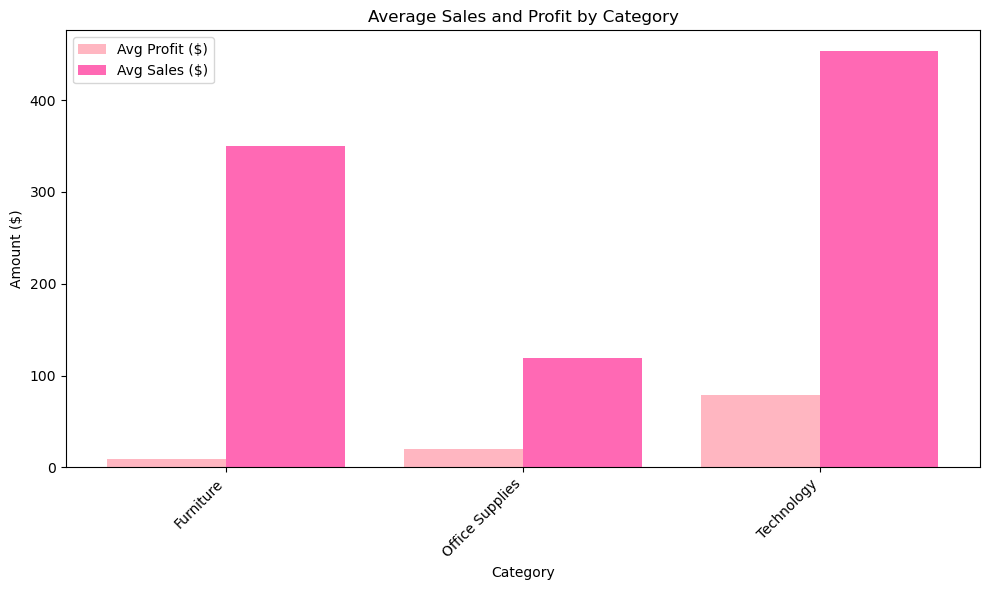

In [142]:
# Assuming df_profit_category has columns: category, avg_profit, avg_sales
categories = df_profit_category['category']
x = np.arange(len(categories))  # label locations
width = 0.4  # width of bars

plt.figure(figsize=(10, 6))

# Plot average profit
plt.bar(x - width/2, df_profit_category['avg_profit'], width, label='Avg Profit ($)', color='lightpink')

# Plot average sales
plt.bar(x + width/2, df_profit_category['avg_sales'], width, label='Avg Sales ($)', color='hotpink')

# Labels and styling
plt.xticks(x, categories, rotation=45, ha='right')
plt.xlabel('Category')
plt.ylabel('Amount ($)')
plt.title('Average Sales and Profit by Category')
plt.legend()
plt.tight_layout()
plt.show()


## Sales by region

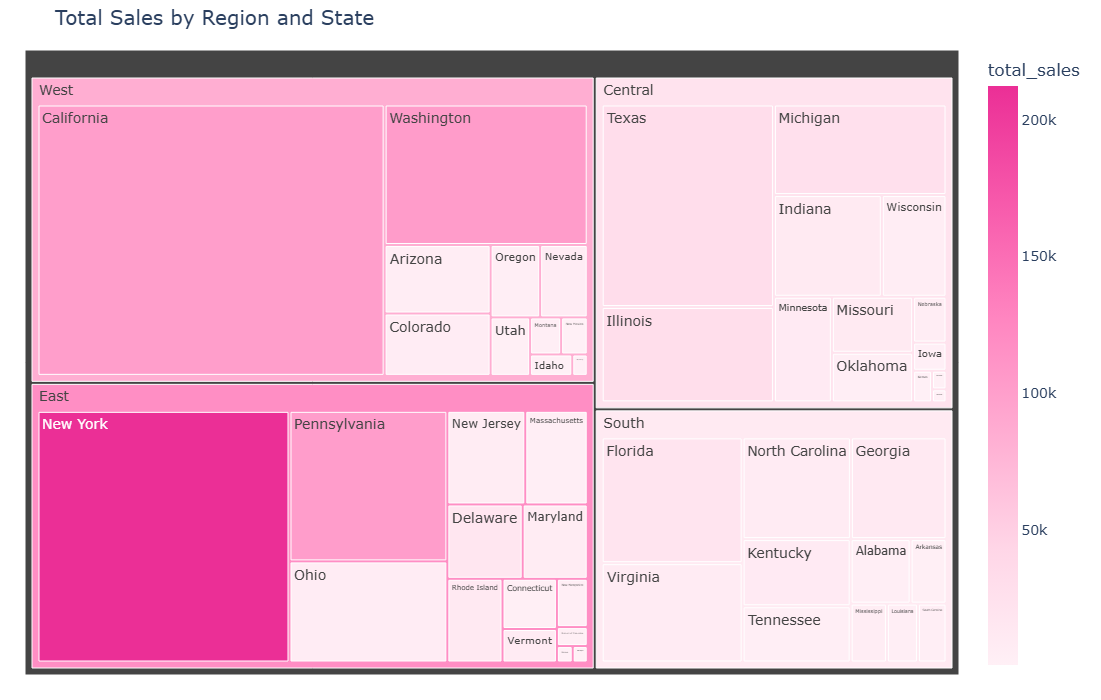

In [150]:
import plotly.express as px

# Custom pink color scale
pink_scale = [
    [0.0, '#fff0f6'],   # lightest pink
    [0.2, '#ffd6e7'],
    [0.4, '#ffadd2'],
    [0.6, '#ff85c0'],
    [0.8, '#f759ab'],
    [1.0, '#eb2f96']     # darkest pink
]

fig = px.treemap(
    df_geo_sales,
    path=['region', 'state'],
    values='total_sales',
    color='total_sales',
    color_continuous_scale=pink_scale,  # Using our custom pink scale
    title='Total Sales by Region and State',
    width=1000,
    height=700
)

# Optional: Adjust layout for better appearance
fig.update_layout(
    margin=dict(t=50, l=25, r=25, b=25),
    font=dict(size=14)
)

fig.show()

## Monthly Sales trend

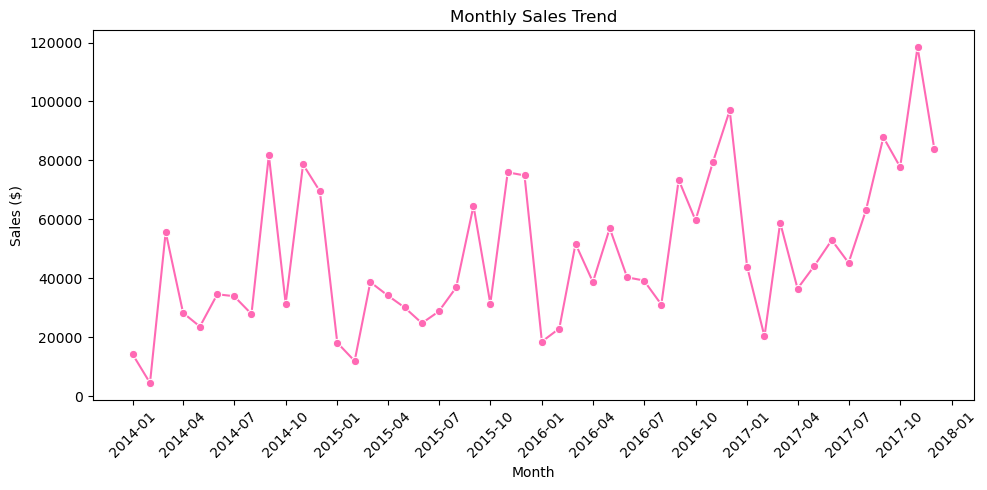

In [156]:
df_monthly_sales['month_dt'] = pd.to_datetime(df_monthly_sales['month'])

plt.figure(figsize=(10, 5))
sns.lineplot(x='month_dt', y='total_sales', data=df_monthly_sales, marker='o', color ='HotPink')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()


## Relationship between discounts and sales

In [93]:
df_discount_sales = run_query("""
    SELECT 
        p.product_name,
        ROUND(AVG(oi.discount), 2) AS avg_discount,
        ROUND(SUM(oi.sales), 2) AS total_sales,
        SUM(oi.quantity) AS total_quantity,
        ROUND(SUM(oi.profit), 2) AS total_profit
    FROM Order_Items oi
    JOIN Products p ON oi.product_id = p.product_id
    GROUP BY p.product_name
    ORDER BY total_sales DESC
    LIMIT 50;
""")


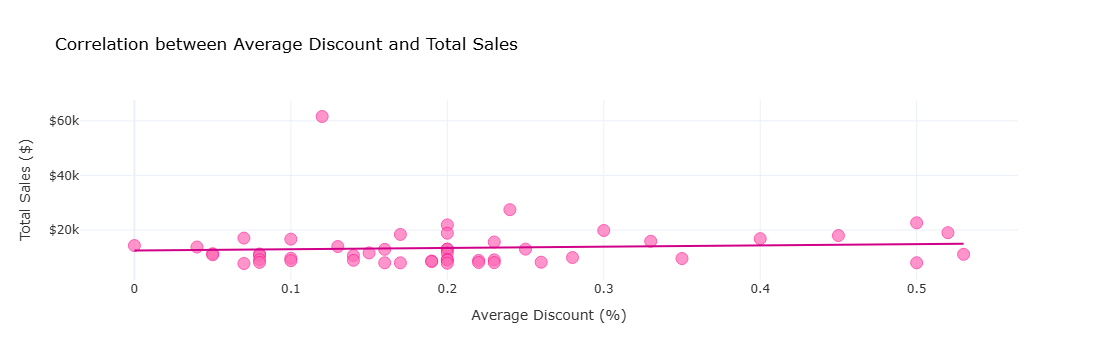

In [164]:
fig = px.scatter(
    df_discount_sales,
    x='avg_discount',
    y='total_sales',
    trendline='ols',
    color_discrete_sequence=['#ff69b4'],  # Hot pink for the dots
    trendline_color_override='#d10088',   # Darker pink for the trendline
    labels={
        'avg_discount': 'Average Discount (%)',
        'total_sales': 'Total Sales ($)'
    },
    title='Correlation between Average Discount and Total Sales'
)

fig.update_layout(
    yaxis=dict(tickprefix="$"),
    template='plotly_white',  # White background template
    plot_bgcolor='white',     # Ensure plot area is white
    paper_bgcolor='white',    # Ensure surrounding area is white
    font=dict(color='#333333'),
    title_font=dict(color='black')  # Deep pink title
)

# Customize marker appearance
fig.update_traces(
    marker=dict(
        size=12,
        opacity=0.7,
        line=dict(width=1, color='#ff1493')  # Border color
    )
)

fig.show()

In [166]:
connection.close()